In [ ]:
import os
import pathlib

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import tensorflow as tf

from tensorflow.keras import layers
from tensorflow.keras import models

from IPython.display import Audio
import librosa.display

In [ ]:
#download mini_speech_commands dataset
DATASET_PATH = 'data/mini_speech_commands'

data_dir = pathlib.Path(DATASET_PATH)
if not data_dir.exists():
  tf.keras.utils.get_file(
      'mini_speech_commands.zip',
      origin="http://storage.googleapis.com/download.tensorflow.org/data/mini_speech_commands.zip",
      extract=True,
      cache_dir='.', cache_subdir='data')

182082353/182082353 [==============================] - 1s 0us/step


In [ ]:
#create a path 'data' for the dataset
dataset_path = 'data/mini_speech_commands'

dataset_contents = os.listdir(dataset_path)
print(dataset_contents)


['left', 'down', 'up', 'yes', 'go', 'stop', 'right', 'README.md', 'no']


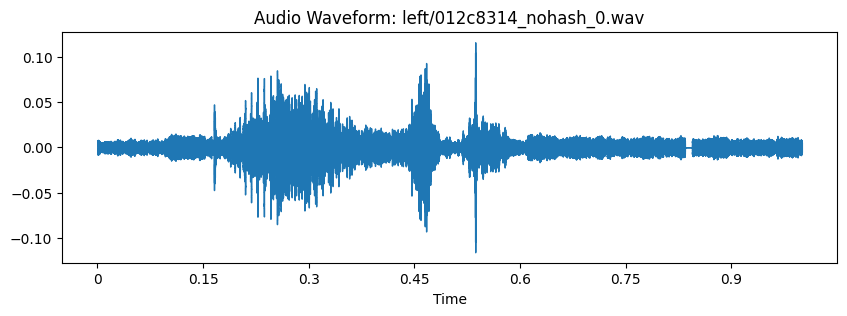

In [ ]:
# displaying Sample wav file
# category_name = 'left'
# audio_file_name = '012c8314_nohash_0.wav'

# Load the specified audio file
audio_data, sample_rate = librosa.load('/content/data/mini_speech_commands/left/012c8314_nohash_0.wav', sr=None)


# Display the audio file and its waveform
plt.figure(figsize=(10, 3))
librosa.display.waveshow(audio_data, sr=sample_rate)
plt.title(f'Audio Waveform: {category_name}/{audio_file_name}')
plt.show()


In [ ]:
# Play the audio file
Audio(audio_data, rate=sample_rate)

In [ ]:
dataset_path = 'data/mini_speech_commands'
output_path = 'data/mel_spectrograms'
os.makedirs(output_path, exist_ok=True)  #creates an output directory

In [ ]:
#splits into training and validation dataset
train_ds, val_ds = tf.keras.utils.audio_dataset_from_directory(
    directory=data_dir,
    batch_size=64,
    validation_split=0.2,
    seed=0,
    output_sequence_length=16000,
    subset='both')
#creating numpy array on label names
label_names = np.array(train_ds.class_names)
print()
print("label names:", label_names)


Found 8000 files belonging to 8 classes.
Using 6400 files for training.
Using 1600 files for validation.

label names: ['down' 'go' 'left' 'no' 'right' 'stop' 'up' 'yes']


In [ ]:
train_ds.element_spec

(TensorSpec(shape=(None, 16000), dtype=tf.float32, name=None),
 TensorSpec(shape=(None,), dtype=tf.int32, name=None))

In [ ]:
#splitting val_ds into 2 for test_ds
test_ds = val_ds.shard(num_shards=2, index=0)
val_ds = val_ds.shard(num_shards=2, index=1)

In [ ]:
validation_size = len(val_ds)
split_index = validation_size // 2

# Create the test dataset by taking the first half
test_ds = val_ds.take(split_index)

# Update the val_ds by skipping the first half
val_ds = val_ds.skip(split_index)


In [ ]:
train_ds.element_spec

(TensorSpec(shape=(None, 16000), dtype=tf.float32, name=None),
 TensorSpec(shape=(None,), dtype=tf.int32, name=None))

In [ ]:
for example_audio, example_labels in train_ds.take(1):
  print(example_audio.shape)
  print(example_labels.shape)


(64, 16000)
(64,)


In [ ]:
label_names[[2,1,3,0]]

array(['left', 'go', 'no', 'down'], dtype='<U5')

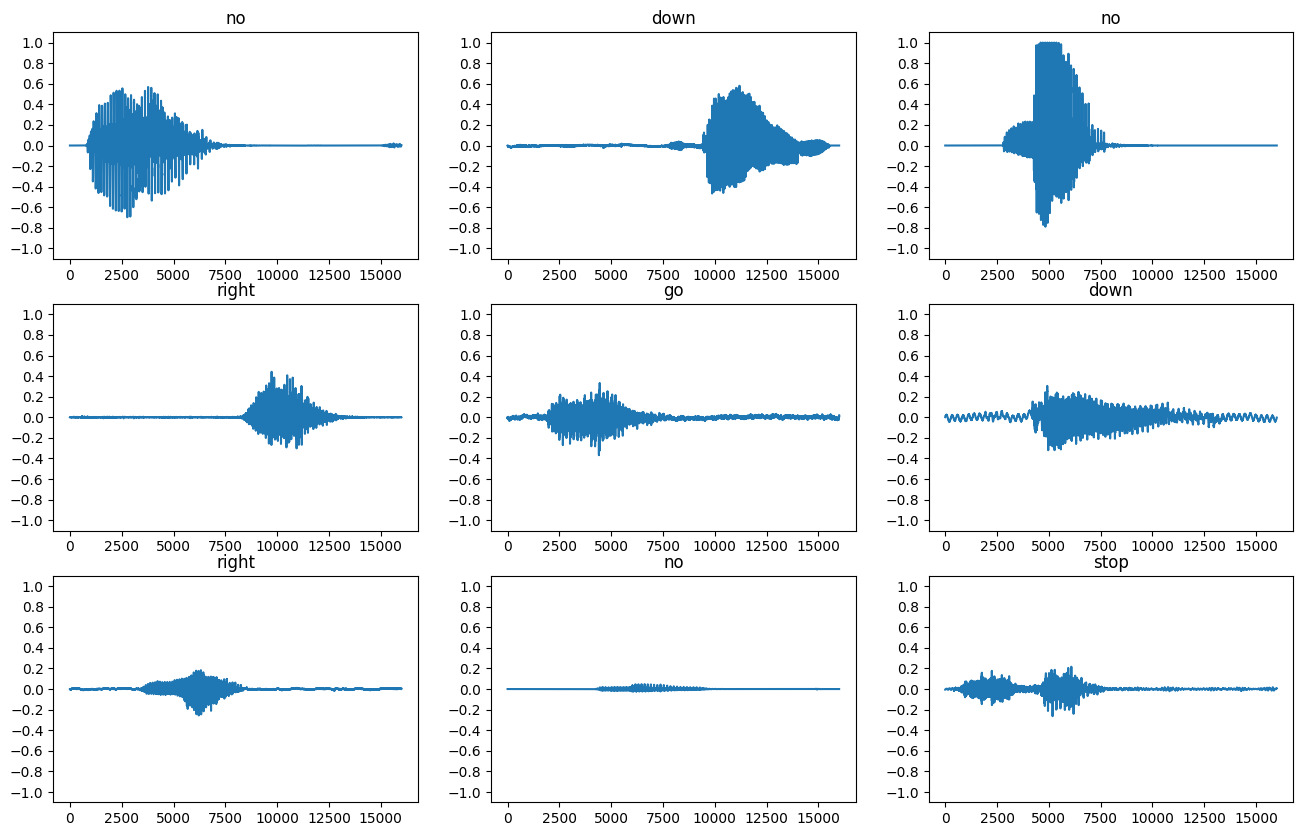

In [ ]:
plt.figure(figsize=(16, 10))
rows = 3
cols = 3
n = rows * cols
for i in range(n):
  plt.subplot(rows, cols, i+1)
  audio_signal = example_audio[i]
  plt.plot(audio_signal)
  plt.title(label_names[example_labels[i]])
  plt.yticks(np.arange(-1.2, 1.2, 0.2))
  plt.ylim([-1.1, 1.1])

In [ ]:
def get_spectrogram(waveform):
  # Convert the waveform to a spectrogram via a STFT.
  spectrogram = tf.signal.stft(
      waveform, frame_length=255, frame_step=128)
  # Obtain the magnitude of the STFT.
  spectrogram = tf.abs(spectrogram)
  # Add a `channels` dimension, so that the spectrogram can be used
  # as image-like input data with convolution layers (which expect
  # shape (`batch_size`, `height`, `width`, `channels`).
  spectrogram = spectrogram[..., tf.newaxis]
  return spectrogram

In [ ]:
for i in range(3):
  label = label_names[example_labels[i]]
  waveform = example_audio[i]
  spectrogram = get_spectrogram(waveform)

  print('Label:', label)
  print('Waveform shape:', waveform.shape)
  print('Spectrogram shape:', spectrogram.shape)


Label: no
Waveform shape: (16000,)
Spectrogram shape: (124, 129, 1)
Label: down
Waveform shape: (16000,)
Spectrogram shape: (124, 129, 1)
Label: no
Waveform shape: (16000,)
Spectrogram shape: (124, 129, 1)


In [ ]:
def plot_spectrogram(spectrogram, ax):
  if len(spectrogram.shape) > 2:
    assert len(spectrogram.shape) == 3
    spectrogram = np.squeeze(spectrogram, axis=-1)
  # Convert the frequencies to log scale and transpose, so that the time is
  # represented on the x-axis (columns).
  # Add an epsilon to avoid taking a log of zero.
  log_spec = np.log(spectrogram.T + np.finfo(float).eps)
  height = log_spec.shape[0]
  width = log_spec.shape[1]
  X = np.linspace(0, np.size(spectrogram), num=width, dtype=int)
  Y = range(height)
  ax.pcolormesh(X, Y, log_spec)

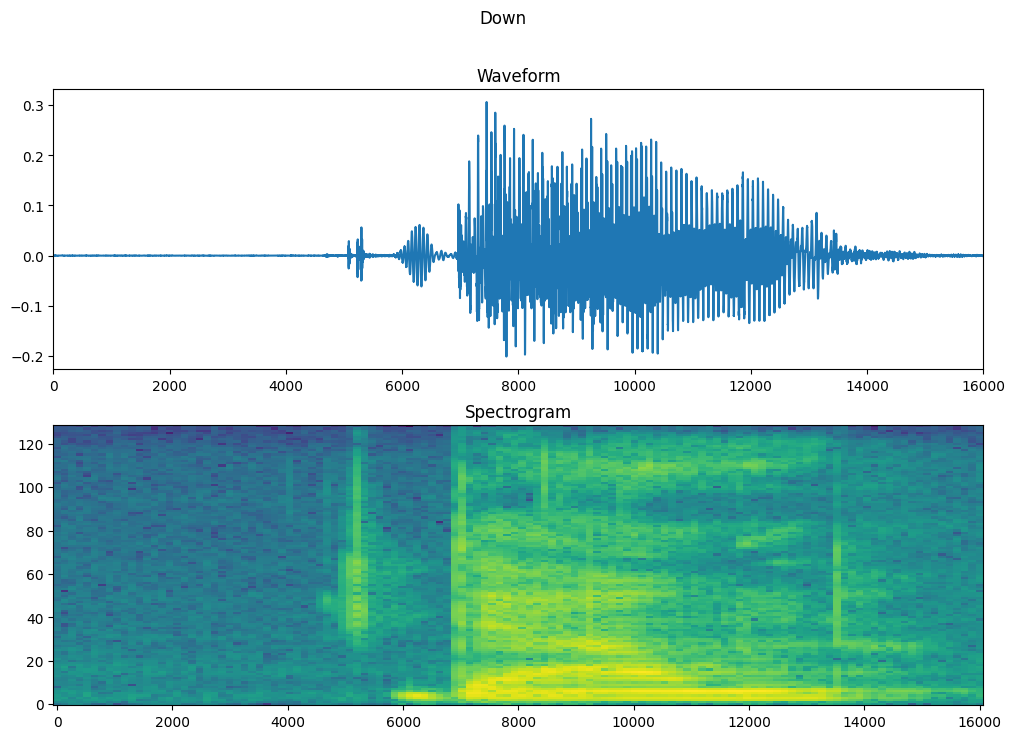

In [ ]:
fig, axes = plt.subplots(2, figsize=(12, 8))
timescale = np.arange(waveform.shape[0])
axes[0].plot(timescale, waveform)
axes[0].set_title('Waveform')
axes[0].set_xlim([0, 16000])

plot_spectrogram(spectrogram, axes[1])
axes[1].set_title('Spectrogram')
plt.suptitle(label.title())
plt.show()

In [ ]:
#creating example_spectrograms which takes 1 batch only from training data
for example_spectrograms, example_spect_labels in train_spectrogram_ds.take(1):
  break

In [ ]:
for i in train_spectrogram_ds:
  print(i[0].shape)
  break

(64, 124, 129, 1)


In [ ]:
#creating datsets for spectrograms
def make_spec_ds(ds):
    def wrapped_get_spectrogram(audio, label):
        spectrogram = tf.py_function(get_spectrogram, [audio], tf.float32)
        return spectrogram, label

    return ds.map(wrapped_get_spectrogram, num_parallel_calls=tf.data.AUTOTUNE)

train_spectrogram_ds = make_spec_ds(train_ds)
val_spectrogram_ds = make_spec_ds(val_ds)
test_spectrogram_ds = make_spec_ds(test_ds)

In [ ]:
example_spectrograms.shape

TensorShape([64, 124, 129, 1])

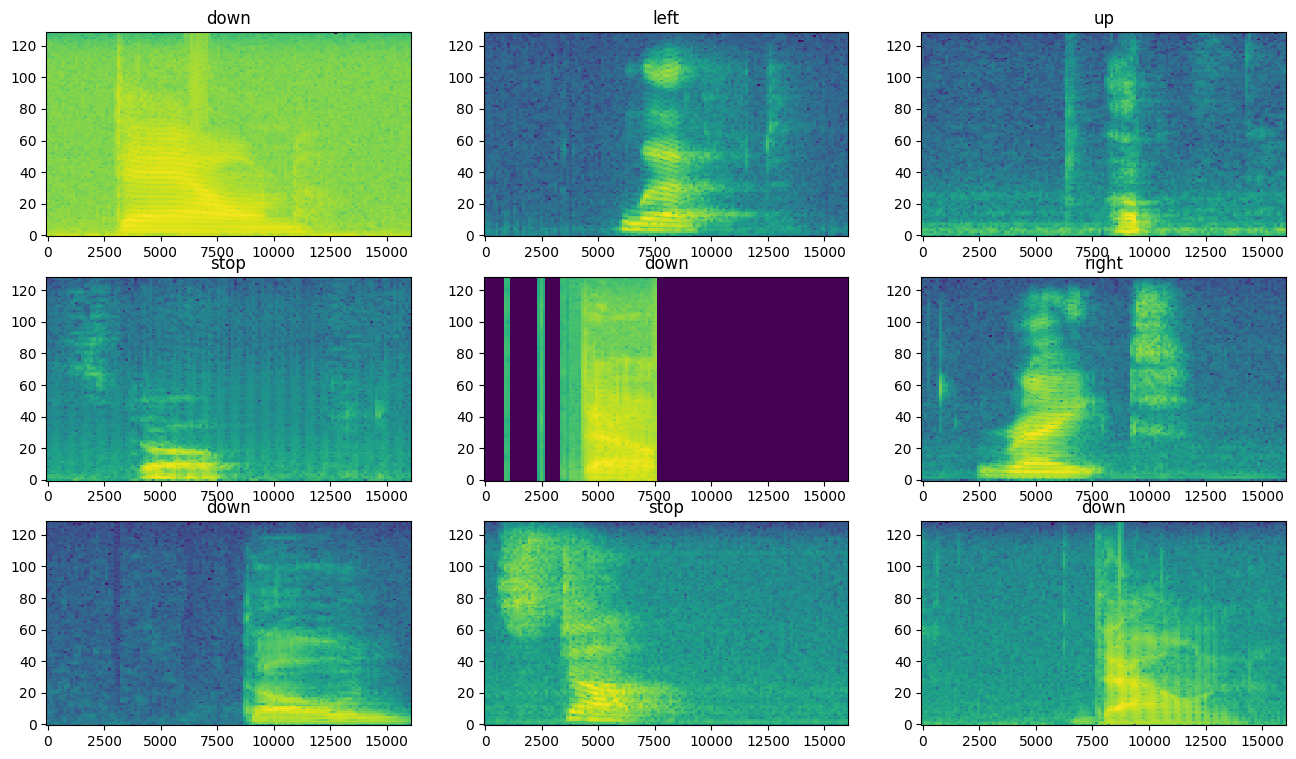

In [ ]:
#displaying first 9 example_spectrograms
rows = 3
cols = 3
fig, axes = plt.subplots(rows, cols, figsize=(16, 9))

for i in range(9):
    r = i // cols
    c = i % cols
    ax = axes[r][c]
    plot_spectrogram(example_spectrograms[i].numpy(), ax)
    ax.set_title(label_names[example_spect_labels[i].numpy()])

plt.show()

In [ ]:
input_shape = example_spectrograms.shape[1:]
print('Input shape:', input_shape)
num_labels = len(label_names)

# Instantiate the `tf.keras.layers.Normalization` layer.
norm_layer = layers.Normalization()
# Fit the state of the layer to the spectrograms
# with `Normalization.adapt`.
norm_layer.adapt(data=train_spectrogram_ds.map(map_func=lambda spec, label: spec))

model = models.Sequential([
    layers.Input(shape=input_shape),
    # Downsample the input.
    layers.Resizing(32, 32),
    # Normalize.
    norm_layer,
    layers.Conv2D(32, 3, activation='relu'),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_labels),
])

model.summary()

Input shape: (124, 129, 1)
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resizing (Resizing)         (None, 32, 32, 1)         0         
                                                                 
 normalization (Normalizati  (None, 32, 32, 1)         3         
 on)                                                             
                                                                 
 conv2d (Conv2D)             (None, 30, 30, 32)        320       
                                                                 
 conv2d_1 (Conv2D)           (None, 28, 28, 64)        18496     
                                                                 
 max_pooling2d (MaxPooling2  (None, 14, 14, 64)        0         
 D)                                                              
                                                                 
 dropout (Dropout)           

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy'],
)

In [ ]:
EPOCHS = 10
history = model.fit(
    train_spectrogram_ds,
    validation_data=val_spectrogram_ds,
    epochs=EPOCHS,
    callbacks=tf.keras.callbacks.EarlyStopping(verbose=1, patience=2),
)

Epoch 1/10
100/100 [==============================] - 35s 350ms/step - loss: 1.7866 - accuracy: 0.3555 - val_loss: 1.3259 - val_accuracy: 0.5833
Epoch 2/10
100/100 [==============================] - 37s 376ms/step - loss: 1.1959 - accuracy: 0.5859 - val_loss: 0.9177 - val_accuracy: 0.6823
Epoch 3/10
100/100 [==============================] - 32s 322ms/step - loss: 0.8846 - accuracy: 0.6878 - val_loss: 0.7822 - val_accuracy: 0.7500
Epoch 4/10
100/100 [==============================] - 32s 324ms/step - loss: 0.7080 - accuracy: 0.7558 - val_loss: 0.6869 - val_accuracy: 0.7604
Epoch 5/10
100/100 [==============================] - 33s 331ms/step - loss: 0.6230 - accuracy: 0.7811 - val_loss: 0.6070 - val_accuracy: 0.7995
Epoch 6/10
100/100 [==============================] - 33s 334ms/step - loss: 0.5489 - accuracy: 0.8103 - val_loss: 0.5898 - val_accuracy: 0.8073
Epoch 7/10
100/100 [==============================] - 32s 319ms/step - loss: 0.4744 - accuracy: 0.8266 - val_loss: 0.5522 - val_ac

Text(0, 0.5, 'Accuracy [%]')

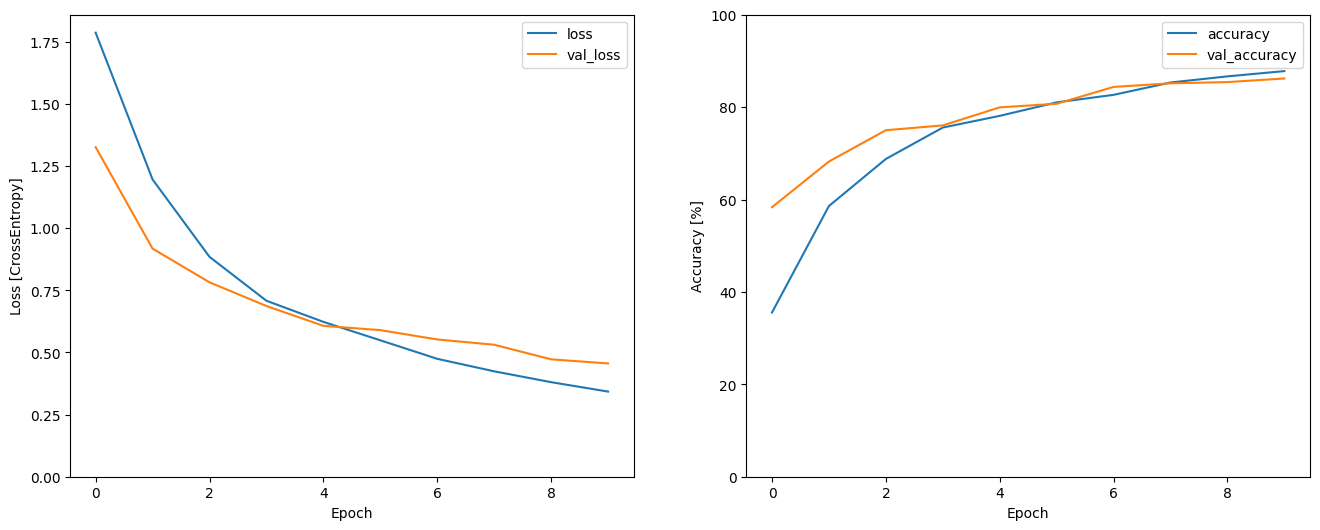

In [ ]:
metrics = history.history
plt.figure(figsize=(16,6))
plt.subplot(1,2,1)
plt.plot(history.epoch, metrics['loss'], metrics['val_loss'])
plt.legend(['loss', 'val_loss'])
plt.ylim([0, max(plt.ylim())])
plt.xlabel('Epoch')
plt.ylabel('Loss [CrossEntropy]')

plt.subplot(1,2,2)
plt.plot(history.epoch, 100*np.array(metrics['accuracy']), 100*np.array(metrics['val_accuracy']))
plt.legend(['accuracy', 'val_accuracy'])
plt.ylim([0, 100])
plt.xlabel('Epoch')
plt.ylabel('Accuracy [%]')

In [ ]:
model.evaluate(test_spectrogram_ds, return_dict=True)

6/6 [==============================] - 3s 503ms/step - loss: 0.4564 - accuracy: 0.8333


{'loss': 0.45644626021385193, 'accuracy': 0.8333333134651184}

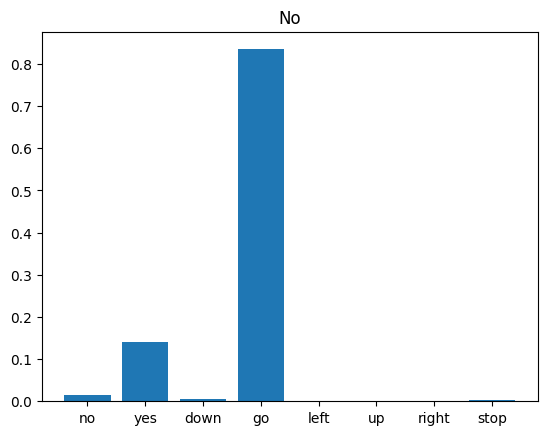

In [ ]:
x = data_dir/'no/01bb6a2a_nohash_0.wav'
x = tf.io.read_file(str(x))
x, sample_rate = tf.audio.decode_wav(x, desired_channels=1, desired_samples=16000,)
x = tf.squeeze(x, axis=-1)
waveform = x
x = get_spectrogram(x)
x = x[tf.newaxis,...]

prediction = model(x)
x_labels = ['no', 'yes', 'down', 'go', 'left', 'up', 'right', 'stop']
plt.bar(x_labels, tf.nn.softmax(prediction[0]))
plt.title('No')
plt.show()


In [ ]:
sample_audio, sample_label = next(iter(train_ds))
if len(sample_audio.shape) == 1:
    print("This audio is mono.")
elif len(sample_audio.shape) == 2:
    print("This audio is stereo (has two channels).")
else:
    print("This audio has an unexpected number of channels.")


This audio is stereo (has two channels).
